In [10]:
import pandas as pd

df = pd.read_csv("final_data (1).csv")

In [11]:
df = pd.read_csv("df_anonymized (2).csv")

Training Model 1 (Ookla QoS)...
Epoch 1/23 - Loss: 1.0836
Epoch 2/23 - Loss: 1.0356
Epoch 3/23 - Loss: 0.9888
Epoch 4/23 - Loss: 0.9397
Epoch 5/23 - Loss: 0.9047
Epoch 6/23 - Loss: 0.8691
Epoch 7/23 - Loss: 0.8539
Epoch 8/23 - Loss: 0.8458
Epoch 9/23 - Loss: 0.8290
Epoch 10/23 - Loss: 0.8183
Epoch 11/23 - Loss: 0.8105
Epoch 12/23 - Loss: 0.8051
Epoch 13/23 - Loss: 0.7921
Epoch 14/23 - Loss: 0.7880
Epoch 15/23 - Loss: 0.7751
Epoch 16/23 - Loss: 0.7836
Epoch 17/23 - Loss: 0.7670
Epoch 18/23 - Loss: 0.7737
Epoch 19/23 - Loss: 0.7588
Epoch 20/23 - Loss: 0.7566
Epoch 21/23 - Loss: 0.7554
Epoch 22/23 - Loss: 0.7596
Epoch 23/23 - Loss: 0.7513


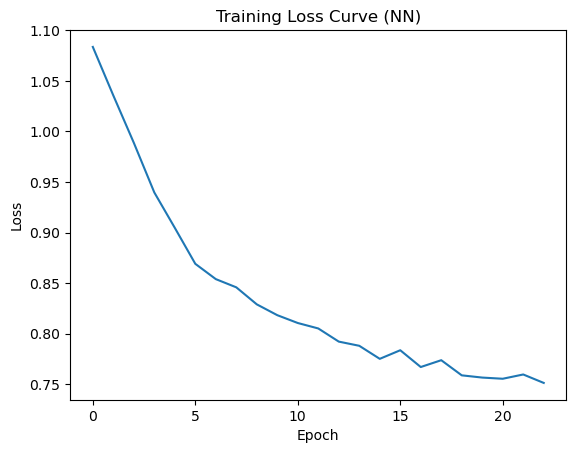

Model 1 saved.

Training Model 2 (Signal Strength)...
Model 2 saved.


In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import joblib
import os
import matplotlib.pyplot as plt

# --- LOGIC ---
def classify_network(download, latency):
    if download >= 25 and latency <= 40:
        return 2
    elif download >= 5 and latency <= 100:
        return 1
    else:
        return 0

# --- MODEL ---
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

def train_ookla_model():
    print("Training Model 1 (Ookla QoS)...")
    df = pd.read_csv("final_data (1).csv")

    df = df[df['avg_d_kbps'] > 0]
    df = df[df['avg_lat_ms'] > 0]

    df['download_mbps'] = df['avg_d_kbps'] / 1000
    df['upload_mbps'] = df['avg_u_kbps'] / 1000
    df['latency_ms'] = df['avg_lat_ms']

    df['target'] = df.apply(lambda row: classify_network(
        row['download_mbps'], row['latency_ms']), axis=1)

    # -------- FEATURE ENGINEERING --------
    df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

    df['latency_bucket'] = pd.cut(
        df['latency_ms'],
        bins=[0, 50, 100, float('inf')],
        labels=[0, 1, 2]
    )
    df['latency_bucket'] = df['latency_bucket'].cat.codes

    df['geo_interaction'] = df['lat'] * df['lon']

    # -------- FINAL FEATURES --------
    features = [
        'upload_mbps',
        'lat',
        'lon',
        'upload_latency_ratio',
        'latency_bucket',
        'geo_interaction'
    ]

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    train_ds = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    model = OoklaNN(input_size=len(features))
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    losses = []

    for epoch in range(23):
        total_loss = 0
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/23 - Loss: {avg_loss:.4f}")

    # --- GRAPH ---
    plt.plot(losses)
    plt.title("Training Loss Curve (NN)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    torch.save(model.state_dict(), 'ookla_nn.pth')
    joblib.dump(scaler, 'ookla_scaler.pkl')
    print("Model 1 saved.")

def train_signal_model():
    print("\nTraining Model 2 (Signal Strength)...")
    
    df = pd.read_csv("df_anonymized (2).csv")

    df['download_mbps'] = df['Downstream Bandwidth'] / 1000
    
    def classify_signal(rsrp, rsrq):
        if rsrp > -85 and rsrq > -12: return 2
        if rsrp > -105 and rsrq > -16: return 1
        return 0

    df['target'] = df.apply(lambda row: classify_signal(
        row['RSRP LTE'], row['RSRQ LTE']), axis=1)

    features = ['RSRP LTE', 'RSRQ LTE', 'SNR LTE', 'CQI LTE', 'dBm']
    df = df.dropna(subset=features)

    X = df[features]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    joblib.dump(model, 'signal_xgb.pkl')
    print("Model 2 saved.")

if __name__ == "__main__":
    train_ookla_model()
    train_signal_model()

In [16]:
import pandas as pd
import torch
import joblib
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# -------- MODEL (same as training) --------
class OoklaNN(torch.nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_size, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.15),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# -------- LOAD DATA --------
df = pd.read_csv("final_data (1).csv")

df = df[df['avg_d_kbps'] > 0]
df = df[df['avg_lat_ms'] > 0]

df['download_mbps'] = df['avg_d_kbps'] / 1000
df['upload_mbps'] = df['avg_u_kbps'] / 1000
df['latency_ms'] = df['avg_lat_ms']

# SAME TARGET
def classify_network(download, latency):
    if download >= 25 and latency <= 40:
        return 2
    elif download >= 5 and latency <= 100:
        return 1
    else:
        return 0

df['target'] = df.apply(lambda row: classify_network(
    row['download_mbps'], row['latency_ms']), axis=1)

# -------- SAME FEATURES --------
df['upload_latency_ratio'] = df['upload_mbps'] / (df['latency_ms'] + 1)

df['latency_bucket'] = pd.cut(
    df['latency_ms'],
    bins=[0, 50, 100, float('inf')],
    labels=[0, 1, 2]
)
df['latency_bucket'] = df['latency_bucket'].cat.codes

df['geo_interaction'] = df['lat'] * df['lon']

features = [
    'upload_mbps',
    'lat',
    'lon',
    'upload_latency_ratio',
    'latency_bucket',
    'geo_interaction'
]

X = df[features]
y = df['target']

# -------- SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------- LOAD SCALER --------
scaler = joblib.load("ookla_scaler.pkl")
X_test_scaled = scaler.transform(X_test)

# -------- LOAD MODEL --------
model = OoklaNN(input_size=6)
model.load_state_dict(torch.load("ookla_nn.pth"))
model.eval()

# -------- PREDICT --------
with torch.no_grad():
    y_pred = model(torch.tensor(X_test_scaled, dtype=torch.float32))
    _, pred = torch.max(y_pred, 1)

# -------- RESULT --------
print("Test Accuracy:", accuracy_score(y_test, pred.numpy()))

Test Accuracy: 0.6898470097357441


In [21]:
new_data = pd.DataFrame([{
    'upload_mbps': 30,
    'lat': 17.38,
    'lon': 78.48,
    'upload_latency_ratio': 30/(30+1),
    'latency_bucket': 0,
    'geo_interaction': 17.38*78.48
}])

new_scaled = scaler.transform(new_data)
new_tensor = torch.tensor(new_scaled, dtype=torch.float32)

with torch.no_grad():
    output = model(new_tensor)
    _, pred = torch.max(output, 1)

classes = ["Poor", "Average", "Good"]
print("Prediction:", classes[pred.item()])

Prediction: Good


In [23]:
import torch
import pandas as pd
import joblib
import torch.nn as nn

# -------- MODEL --------
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# -------- LOAD MODEL + SCALER --------
model = OoklaNN(input_size=6)
model.load_state_dict(torch.load("ookla_nn.pth"))
model.eval()

scaler = joblib.load("ookla_scaler.pkl")

# -------- UNSEEN DATA (AVERAGE) --------
new_data = pd.DataFrame([{
    'upload_mbps': 10,
    'lat': 17.38,
    'lon': 78.48,
    'upload_latency_ratio': 10/(60+1),
    'latency_bucket': 1,
    'geo_interaction': 17.38*78.48
}])

# -------- SCALE + PREDICT --------
new_scaled = scaler.transform(new_data)
new_tensor = torch.tensor(new_scaled, dtype=torch.float32)

with torch.no_grad():
    output = model(new_tensor)
    _, pred = torch.max(output, 1)

classes = ["Poor", "Average", "Good"]
print("Prediction:", classes[pred.item()])

Prediction: Average


In [24]:
import torch
import pandas as pd
import joblib
import torch.nn as nn

# -------- MODEL --------
class OoklaNN(nn.Module):
    def __init__(self, input_size):
        super(OoklaNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.network(x)

# -------- LOAD MODEL + SCALER --------
model = OoklaNN(input_size=6)
model.load_state_dict(torch.load("ookla_nn.pth"))
model.eval()

scaler = joblib.load("ookla_scaler.pkl")

# -------- UNSEEN DATA (POOR) --------
new_data = pd.DataFrame([{
    'upload_mbps': 2,
    'lat': 17.38,
    'lon': 78.48,
    'upload_latency_ratio': 2/(150+1),
    'latency_bucket': 2,
    'geo_interaction': 17.38*78.48
}])

# -------- SCALE + PREDICT --------
new_scaled = scaler.transform(new_data)
new_tensor = torch.tensor(new_scaled, dtype=torch.float32)

with torch.no_grad():
    output = model(new_tensor)
    _, pred = torch.max(output, 1)

classes = ["Poor", "Average", "Good"]
print("Prediction:", classes[pred.item()])

Prediction: Poor
